In [ ]:
import pandas as pd
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # data visualization
from datetime import date # to calculate ages of users
from IPython.display import display # to display decriptive statistics
from google.colab import files # to upload files
import numpy as np
import re # for text analysis
import pytz # for timezone conversions


'''for text analysis'''
import string
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams

nltk.download('stopwords')


# uploading the dataset
uploaded = files.upload()
df = pd.read_csv("sentiment.csv")

# creating an auxilliary df that stores all of the columns as strings for easier filtering
# removing "?" from the target variable column
df_str = df.astype(str)
df_str = df_str[df_str['sentiment'] != '?']

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving sentiment.csv to sentiment (3).csv


### $\textbf{הצגת התפלגויות של המשתנים}$

count    38987.000000
mean       349.622438
std       1302.335599
min         20.000000
25%         57.000000
50%         85.000000
75%        183.500000
max      29508.000000
Name: post_likes, dtype: float64


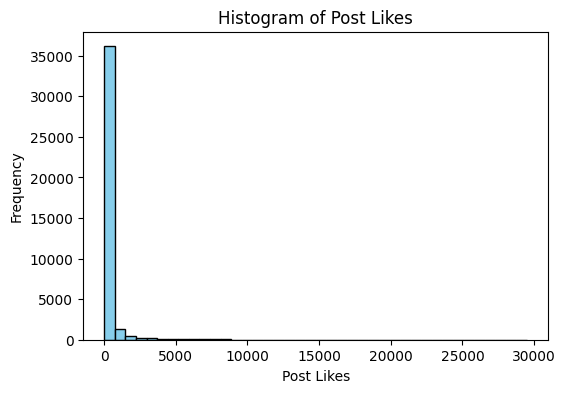

In [ ]:
'''DATA DISTRIBUTIONS FOR NUMERICAL VARIABLES'''

'''POST LIKES'''

user_data_likes = df_str[df_str['post_likes'] != "?"]['post_likes']
user_data_likes = pd.to_numeric(user_data_likes, errors='coerce')

# descriptive statistics
print(user_data_likes.describe())


plt.figure(figsize=(6, 4))

# histogram
plt.hist(user_data_likes, bins=40, color='skyblue', edgecolor='black')
plt.title('Histogram of Post Likes')
plt.xlabel('Post Likes')
plt.ylabel('Frequency')

plt.show()

count    38987.000000
mean        48.466386
std        274.951827
min          0.000000
25%          3.000000
50%         10.000000
75%         26.000000
max      16679.000000
Name: posts_retweets, dtype: float64


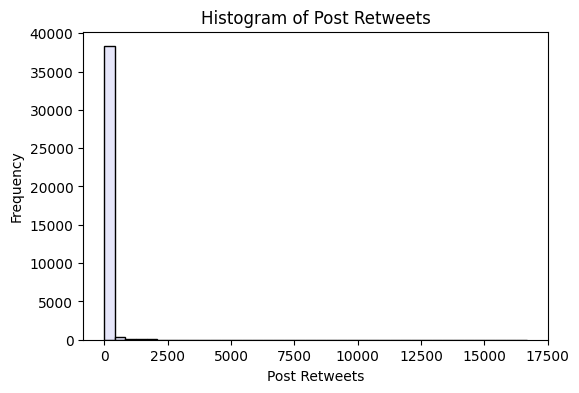

In [ ]:
'''POST RETWEETS'''

user_data_retweets = df_str[df_str['posts_retweets'] != "?"]['posts_retweets']
user_data_retweets = pd.to_numeric(user_data_retweets, errors='coerce')

# descriptive statistics
print(user_data_retweets.describe())

plt.figure(figsize=(6, 4))

# histogram
plt.hist(user_data_retweets, bins=40, color='lavender', edgecolor='black')
plt.title('Histogram of Post Retweets')
plt.xlabel('Post Retweets')
plt.ylabel('Frequency')

plt.show()

count    38486.000000
mean        34.824586
std         13.270260
min          8.000000
25%         26.000000
50%         33.000000
75%         40.000000
max        104.000000
Name: age, dtype: float64


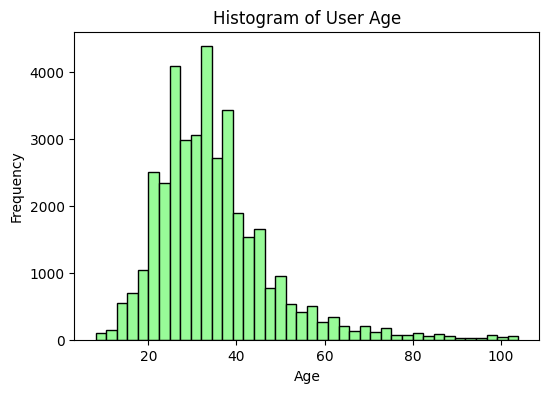

In [ ]:
'''AGE AT POST'''

user_data_age_at_post = df_str[(df_str['birthday'] != "?") & (df_str['post_datetime'] != "?")][['birthday', 'post_datetime']]
user_data_age_at_post['birthday'] = pd.to_datetime(user_data_age_at_post['birthday'])
user_data_age_at_post['post_datetime'] = pd.to_datetime(user_data_age_at_post['post_datetime'])

# transform birthday to age at post using apply
user_data_age_at_post['age'] = user_data_age_at_post.apply(lambda row: calculate_age(row['birthday'], row['post_datetime']), axis=1)

user_data_age_at_post = pd.to_numeric(user_data_age_at_post['age'], errors='coerce')


print(user_data_age_at_post.describe())

plt.figure(figsize=(6, 4))

# histogram
plt.hist(user_data_age_at_post, bins=40, color='palegreen', edgecolor='black')
plt.title('Histogram of User Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

count     38993.000000
mean        485.601698
std        2591.270046
min           0.000000
25%          39.000000
50%         104.000000
75%         265.000000
max      120692.000000
Name: followers, dtype: float64


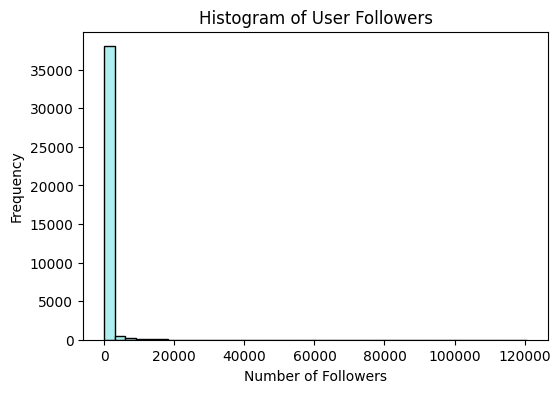

In [ ]:
'''FOLLOWERS'''

user_data_followers = df_str[df_str['followers'] != "?"]['followers']

user_data_followers = pd.to_numeric(user_data_followers, errors='coerce')

# descriptive statistics
print(user_data_followers.describe())


plt.figure(figsize=(6, 4))

# histogram
plt.hist(user_data_followers, bins=40, color='paleturquoise', edgecolor='black')
plt.title('Histogram of User Followers')
plt.xlabel('Number of Followers')
plt.ylabel('Frequency')

plt.show()

count    38993.000000
mean       105.135819
std         87.072767
min          0.000000
25%         42.000000
50%         82.000000
75%        145.000000
max        679.000000
Name: previous_posts_count, dtype: float64


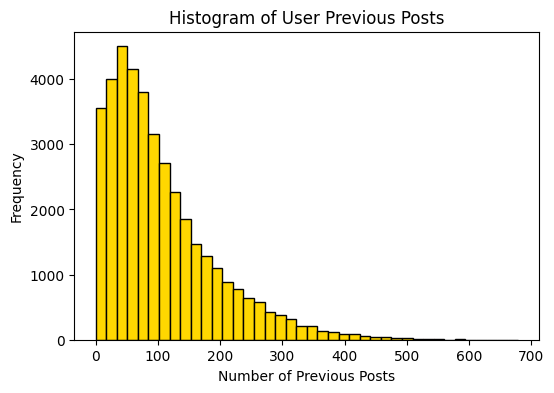

In [ ]:
'''PREVIOUS POSTS COUNT'''

user_data_prev_posts = df_str[df_str['previous_posts_count'] != "?"]['previous_posts_count']

user_data_prev_posts = pd.to_numeric(user_data_prev_posts, errors='coerce')

# descriptive statistics
print(user_data_prev_posts.describe())


plt.figure(figsize=(6, 4))

# histogram
plt.hist(user_data_prev_posts, bins=40, color='gold', edgecolor='black')
plt.title('Histogram of User Previous Posts')
plt.xlabel('Number of Previous Posts')
plt.ylabel('Frequency')

plt.show()

$\textbf{הצגת תרשים קופסא והיסטוגרמה מצומצמת עבור המשתנים עם זנב ארוך}$

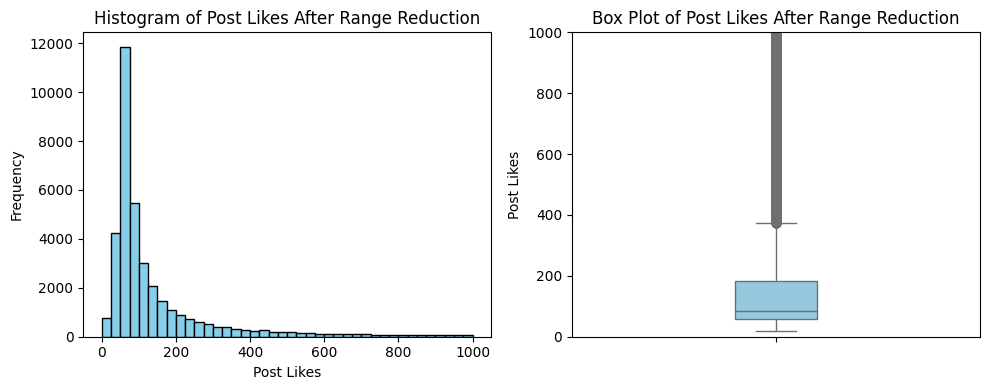

In [ ]:
'''POST LIKES VISUALIZATION AFTER RANGE REDUCTION'''

user_data_likes = df_str[df_str['post_likes'] != "?"]['post_likes']
user_data_likes = pd.to_numeric(user_data_likes, errors='coerce')


plt.figure(figsize=(10,4))

# histogram
plt.subplot(1, 2, 1)
plt.hist(user_data_likes, bins=40, range = (0,1000), color='skyblue', edgecolor='black')
plt.title('Histogram of Post Likes After Range Reduction')
plt.xlabel('Post Likes')
plt.ylabel('Frequency')


# boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=user_data_likes, color='skyblue', width=0.2)
plt.title(f'Box Plot of Post Likes After Range Reduction')
plt.ylabel('Post Likes')
plt.ylim(0, 1000)

plt.tight_layout()
plt.show()




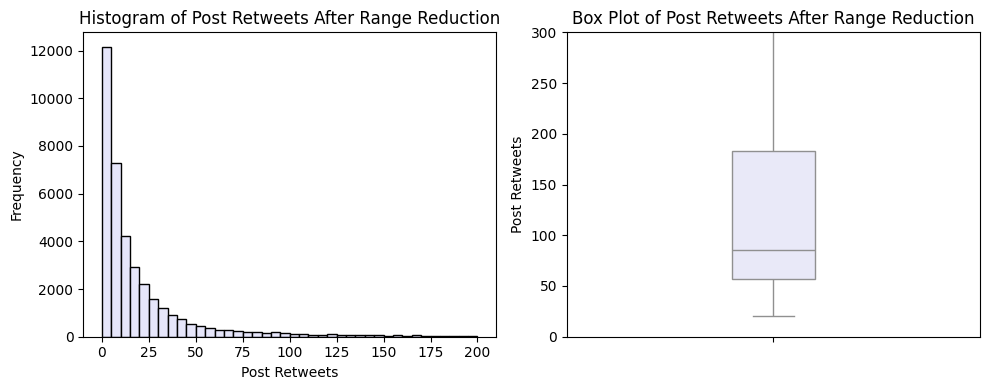

In [ ]:

'''POSTS RETWEETS VISUALIZATION AFTER RANGE REDUCTION'''
user_data_retweets = df_str[df_str['posts_retweets'] != "?"]['posts_retweets']
user_data_retweets = pd.to_numeric(user_data_retweets, errors='coerce')

plt.figure(figsize=(10, 4))

# histogram
plt.subplot(1, 2, 1)
plt.hist(user_data_retweets, range=(0,200), bins=40, color='lavender', edgecolor='black')
plt.title('Histogram of Post Retweets After Range Reduction')
plt.xlabel('Post Retweets')
plt.ylabel('Frequency')


# boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=user_data_likes, color='lavender', width=0.2)
plt.title(f'Box Plot of Post Retweets After Range Reduction')
plt.ylabel('Post Retweets')
plt.ylim(0, 300)

plt.tight_layout()
plt.show()

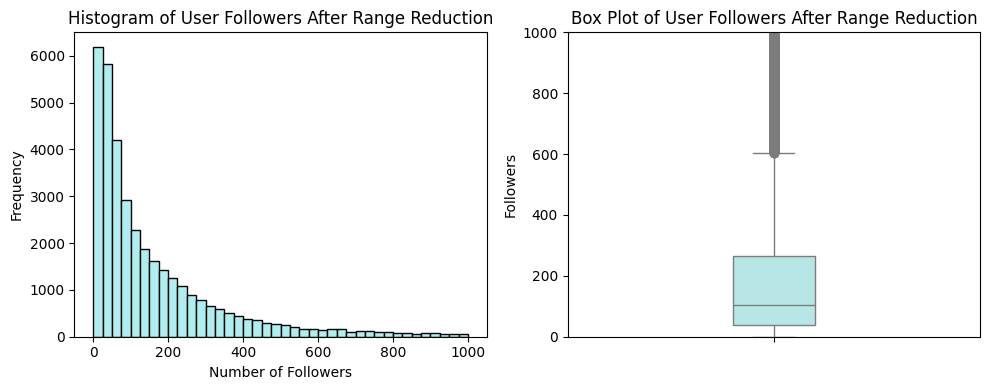

In [ ]:
'''FOLLOWERS VISUALIZATION AFTER RANGE REDUCTION'''
user_data_followers = df_str[df_str['followers'] != "?"]['followers']
user_data_followers = pd.to_numeric(user_data_followers, errors='coerce')

# Create histogram and box plot
plt.figure(figsize=(10, 4))

# histogram
plt.subplot(1, 2, 1)
plt.hist(user_data_followers, range = (0,1000), bins=40, color='paleturquoise', edgecolor='black')
plt.title('Histogram of User Followers After Range Reduction')
plt.xlabel('Number of Followers')
plt.ylabel('Frequency')


# boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=user_data_followers, color='paleturquoise', width=0.2)
plt.title(f'Box Plot of User Followers After Range Reduction')
plt.ylabel('Followers')
plt.ylim(0, 1000)

plt.tight_layout()
plt.show()


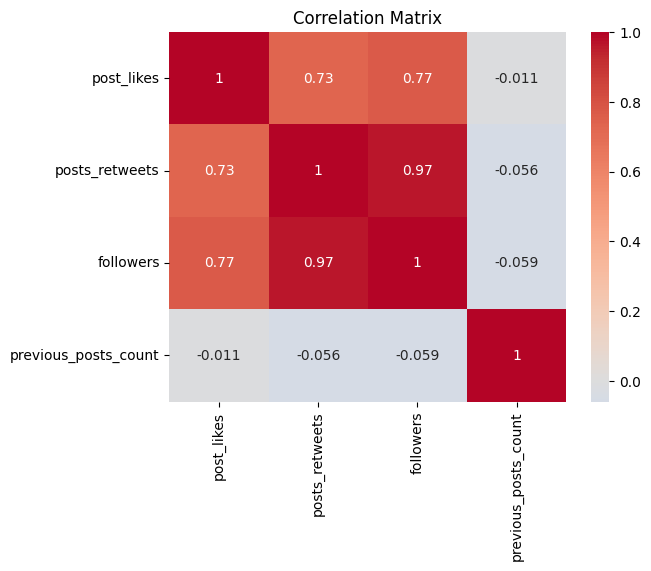

In [ ]:
'''ANALYZING RELATIONSHIPS BETWEEN NUMERICAL VARIABLES'''

df_numerical_correlations = df_str[
    (df_str['post_likes'] != "?") &
    (df_str['posts_retweets'] != "?") &
    (df_str['followers'] != "?") &
    (df_str['previous_posts_count'] != "?")
][['post_likes', 'posts_retweets', 'followers', 'previous_posts_count']]

# Convert these columns to numeric
df_numerical_correlations = df_numerical_correlations.apply(pd.to_numeric, errors='coerce')


# Calculate the correlation matrix
corr_matrix = df_numerical_correlations.corr()

# Plotting the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


$\textbf{פונקציות לניתוח של משתנים קטגוריאליים}$

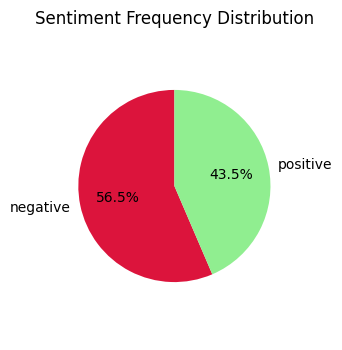

In [ ]:
'''DATA DISTRIBUTIONS FOR CATEGORICAL VARIABLES'''

custom_colors_sentiment = ['crimson', 'lightgreen']

'''SENTIMENT'''

groupby = df_str['sentiment'].value_counts()
percentages = groupby / groupby.sum() * 100

distribution = pd.DataFrame({
        'Category': groupby.index,
        'Count': groupby.values,
        'Percent': percentages.values
})

plt.figure(figsize=(6, 4))

# pie chart
plt.subplot(1, 2, 2)
plt.pie(distribution['Percent'], labels=distribution['Category'], autopct='%1.1f%%', startangle=90, colors=custom_colors_sentiment)
plt.axis('equal')
plt.title('Sentiment Frequency Distribution')
plt.show()



'''STACKED BAR PLOT FOR CATEGORICAL VARIABLES'''
def plot_normalized_stacked_by_category(df, categorical_column, sentiment_column='sentiment', palette=custom_colors_sentiment):
    """
    Stacked bar plot where each category (x-axis) shows sentiment distribution,
    normalized by total count in each sentiment group.
    """
    # Clean data
    df_clean = df_str[(df_str[categorical_column] != "?") & (df_str[sentiment_column] != "?")]

    # Count occurrences
    counts = df_clean.groupby([categorical_column, sentiment_column]).size().reset_index(name='Count')

    # Pivot to get matrix form
    pivot = counts.pivot(index=categorical_column, columns=sentiment_column, values='Count').fillna(0)

    # Normalize each column (sentiment) to 100%
    normalized = pivot.div(pivot.sum(axis=0), axis=1) * 100

    # Plot
    ax = normalized.plot(kind='bar', stacked=True, figsize=(8, 8), color=sns.color_palette(palette), width = 0.4)

    plt.ylabel("Percentage within Sentiment")
    plt.xlabel(categorical_column.capitalize())
    plt.title(f"{categorical_column.capitalize()} Distribution within Each Sentiment")
    plt.legend(title='Sentiment', loc = 'upper right')
    plt.xticks(rotation=45, ha='right')

    # Add value labels
    for i, category in enumerate(normalized.index):
        cumulative = 0
        for sentiment in normalized.columns:
            height = normalized.loc[category, sentiment]
            if height > 0:
                ax.text(i, cumulative + height / 2, f'{height:.1f}%', ha='center', va='center', fontsize=9)
                cumulative += height

    plt.tight_layout()
    plt.show()




def plot_normalized_by_category(df, categorical_column, sentiment_column='sentiment', palette=custom_colors_sentiment,
                                 x_label=None, y_label=None, title=None, legend_title='Sentiment',
                                 show_percentages=True, custom_xtick_labels=None, y_top_margin=10,
                                 order=None,figsize=(6,4)):
    """
    Plot normalized sentiment distribution for a given categorical column.

    Args:
    - df: dataframe containing the data
    - categorical_column: name of the categorical column
    - sentiment_column: name of the sentiment column
    - palette: color palette for the plots
    - x_label: label for the x-axis
    - y_label: label for the y-axis
    - title: title of the plot
    - legend_title: title for the legend
    - show_percentages: whether to display percentages on the bars
    - custom_xtick_labels: custom labels for the x-axis ticks
    - y_top_margin: Extra margin at the top of the y-axis for labels
    - order: list specifying the order of the categories on the x-axis
    - figsize: size of the plot
    """


    # group by category and sentiment and count
    counts = df.groupby([categorical_column, sentiment_column]).size().reset_index(name='Count')

    pivot = counts.pivot(index=categorical_column, columns=sentiment_column, values='Count').fillna(0)

    # normalizing each sentiment column to 100%
    normalized = pivot.div(pivot.sum(axis=0), axis=1) * 100

    # apply order if given
    if order:
        normalized = normalized.reindex(order)

    # plot
    ax = normalized.plot(kind='bar', stacked=False, figsize=figsize,
                         color=sns.color_palette(palette), width=0.4)

    # setting labels
    plt.ylabel(y_label if y_label else "Percentage of Posts By Sentiment")
    plt.xlabel(x_label.capitalize() if x_label else categorical_column.capitalize())
    plt.title(title if title else f"Post Sentiment Percentage by {x_label}")
    plt.legend(title=legend_title, loc='upper right')

    # Custom tick labels
    if custom_xtick_labels:
        xticks_labels = [label.get_text() for label in ax.get_xticklabels()]
        new_x_labels = [custom_xtick_labels.get(label, label) for label in xticks_labels]
        ax.set_xticks(range(len(xticks_labels)))
        ax.set_xticklabels(new_x_labels, rotation=45, ha='right')
    else:
        plt.xticks(rotation=45, ha='right')

    # adding percentages
    if show_percentages:
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f'{height:.1f}%',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', fontsize=9)

    # adjusting y-axis
    max_percentage = normalized.max().max()
    ax.set_ylim(0, max_percentage + y_top_margin)

    plt.tight_layout()
    plt.show()



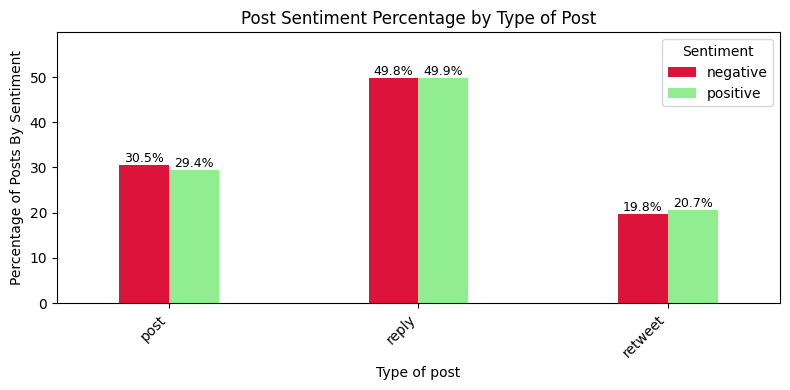

In [ ]:
'''TYPE OF POST'''
plot_normalized_by_category(df_str[df_str['type'] != "?"],
                            'type',
                            x_label="Type of Post",
                            figsize=(8,4))



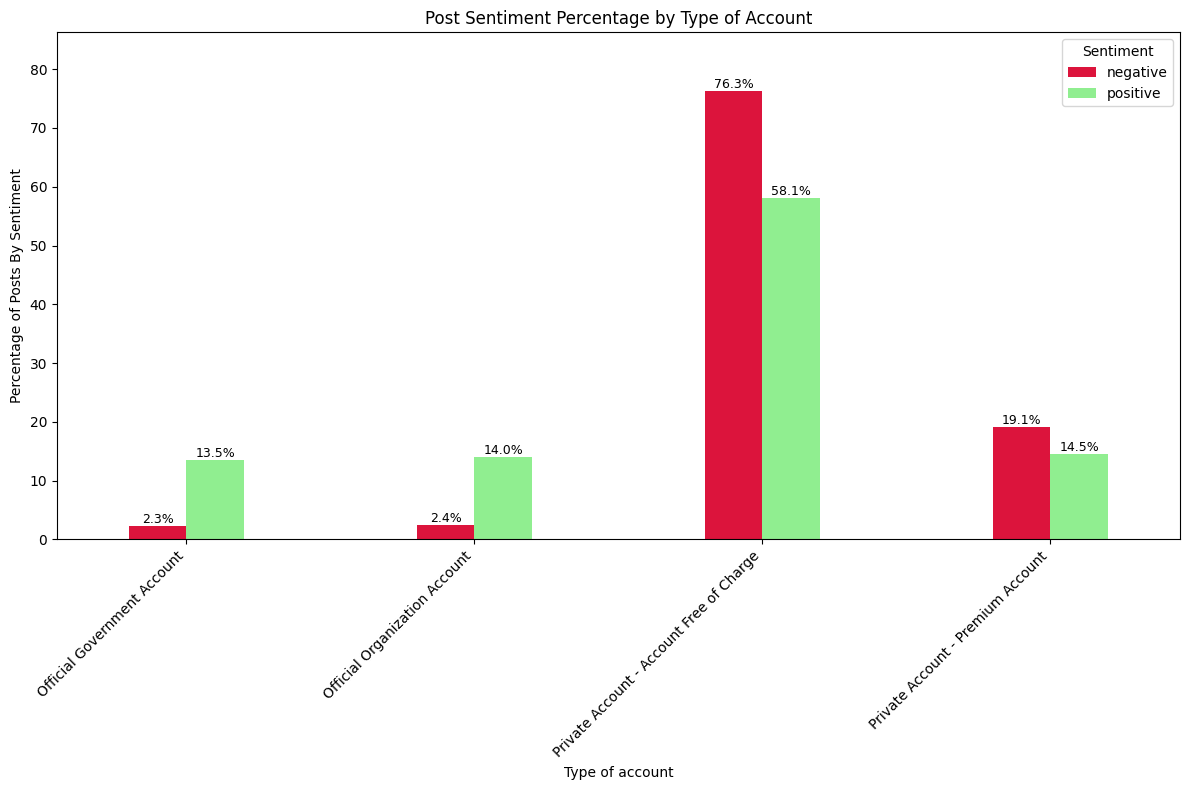

In [ ]:
'''CHECKMARK'''
checkmark_dict = {
    "none": "Private Account - Account Free of Charge",
    "blue": "Private Account - Premium Account",
    "gold": "Official Organization Account",
    "grey": "Official Government Account"
}

df_checkmark = df_str.copy()
df_checkmark = df_checkmark[df_checkmark['checkmark'] != "?"]
df_checkmark['checkmark_description'] = df_checkmark['checkmark'].map(checkmark_dict)

plot_normalized_by_category(df_checkmark,
                            'checkmark_description',
                            x_label="Type of Account",
                            figsize=(12,8))

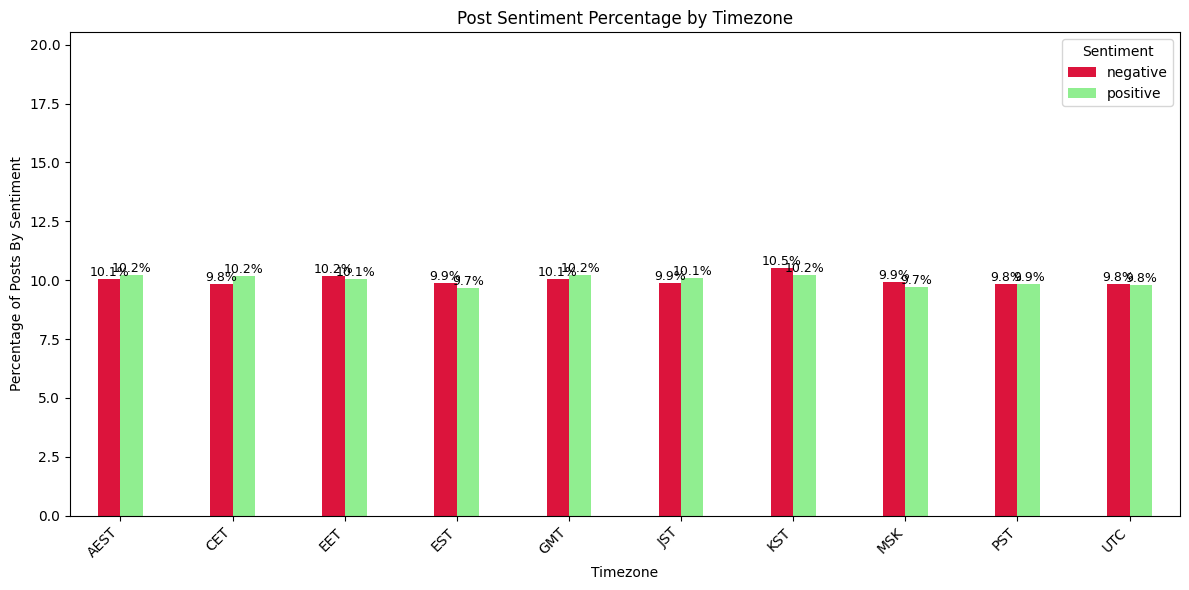

In [ ]:
'''TIMEZONE'''
plot_normalized_by_category(df_str[df_str['timezone'] != "?"],
                            'timezone',
                            x_label="Timezone",
                            figsize=(12,6))

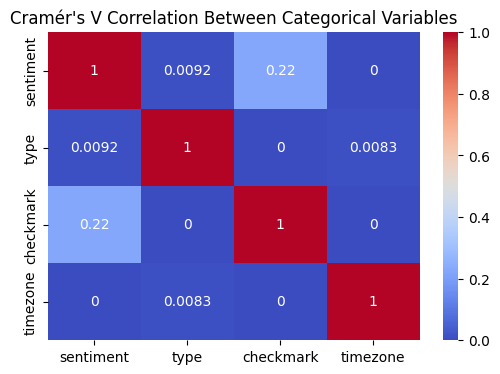

In [ ]:
import scipy.stats as stats

df_categorial_correlations = df_str[
    (df_str['sentiment'] != "?") &
    (df_str['type'] != "?") &
    (df_str['checkmark'] != "?") &
    (df_str['timezone'] != "?")
][['sentiment','type','checkmark','timezone']]

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2_corr / min((k_corr-1), (r_corr-1)))



categorical_cols = ['sentiment', 'type', 'checkmark', 'timezone']  # choose your columns
results = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        results.loc[col1, col2] = cramers_v(df[col1], df[col2])

results = results.astype(float)

plt.figure(figsize=(6,4))
sns.heatmap(results, annot=True, cmap='coolwarm')
plt.title("Cramér's V Correlation Between Categorical Variables")
plt.show()


$\textbf{פונקציות לעיבוד נתונים גולמיים - יצירת פיצ'רים}$

In [ ]:
'''REGION'''
# mapping of timezone abbreviations to regions or continents - for informative purposes
timezone_to_region = {
    # timezones found in data using unique() method
    'AEST': 'Australia',
    'EET': 'Europe/Eastern Europe',
    'GMT': 'Europe/Africa',
    'MSK': 'Europe/Russia',
    'PST': 'North America/United States',
    'CET': 'Europe/Central Europe',
    'EST': 'North America/United States',
    'KST': 'Asia/South Korea',
    'UTC': 'Global',
    'JST': 'Asia/Japan'
}


'''HOUR OF POST'''
# mapping of timezone abbreviations to regions or continents - for time conversion purposes
timezone_to_iana = {
    'AEST': 'Australia/Sydney',
    'EET': 'Europe/Helsinki',
    'GMT': 'Etc/GMT',
    'MSK': 'Europe/Moscow',
    'PST': 'America/Los_Angeles',
    'CET': 'Europe/Paris',
    'EST': 'America/New_York',
    'KST': 'Asia/Seoul',
    'UTC': 'UTC',
    'JST': 'Asia/Tokyo'
}


def calculate_age(birth_date, post_datetime):
    """Calculates age at the time of the post."""
    birth_date = pd.to_datetime(birth_date)
    post_date = pd.to_datetime(post_datetime)

    return post_date.year - birth_date.year - (
        (post_date.month, post_date.day) < (birth_date.month, birth_date.day)
    )


def localize_post_time(post_time, timezone_key):
    """
    Localizes a naive datetime to the correct timezone using IANA mapping.
    If already timezone-aware, converts to the correct timezone.
    Uses modern zoneinfo (Python 3.9+).

    Args:
        post_time (datetime): naive or aware datetime
        timezone_key (str): abbreviation like 'EST', 'CET', etc.

    Returns:
        datetime: timezone-aware datetime
    """
    iana_name = timezone_to_iana.get(timezone_key)
    if not iana_name:
        raise ValueError(f"Unknown timezone key: {timezone_key}")

    if post_time.tzinfo is None:
        # Naive: attach timezone directly
        return post_time.replace(tzinfo=ZoneInfo(iana_name))
    else:
        # Aware: convert to target timezone
        return post_time.astimezone(ZoneInfo(iana_name))


def get_slot_of_day(dt):
  """
  Extracts the hour from a datetime object and determines if it's morning, noon,
  afternoon, evening, or night.

  Args:
    dt: A datetime object.

  Returns:
    A string indicating the time of day ('Morning', 'Noon', 'Afternoon', 'Evening', or 'Night').
  """
  hour = dt.hour
  if 6 <= hour < 12:
    return 'Morning'
  elif 12 <= hour < 14:
    return 'Noon'
  elif 14 <= hour < 18:
    return 'Afternoon'
  elif 18 <= hour <= 23:
    return 'Evening'
  else:
    return 'Night'



def classify_and_get_content_type(url):
    """
    Determines the content type of a URL based on its extension or domain.

    Args:
    url: A string containing a URL.

    Returns:
    A string representing the type of content:
      - 'missing' if the URL is NaN or an empty string.
      - 'image' if the URL ends with an image extension like .jpg, .jpeg, .png, .gif, .bmp, or webp.
      - 'video' if the URL belongs to a video platform like YouTube, Vimeo, or Dailymotion.
      - 'other' for URLs with an unsupported extension.
      - 'link' for any other URL type not matching the above categories.
    """
    # Check if the URL is missing or empty
    if pd.isna(url) or str(url).strip() == '':
        return 'missing'

    # Convert the URL to lowercase and strip any surrounding whitespace
    url = url.lower().strip()

    # Split the URL and get the last part (after the last '/')
    last_part = url.split('/')[-1]

    # If the URL contains a file extension
    if '.' in last_part:
        # Extract the file extension
        ext = last_part.split('.')[-1].split('?')[0].split('#')[0]

        # Check the file extension and categorize it
        if ext in ['jpg', 'jpeg', 'png', 'gif', 'bmp', 'webp']:
            return 'image'
        elif ext in ['mp4', 'avi', 'mov', 'wmv', 'mkv', 'webm']:
            return 'video'
        else:
            return 'other'

    # If the URL belongs to a known video platform
    elif re.search(r'youtube\.com|vimeo\.com|dailymotion\.com', url, re.IGNORECASE):
        return 'video'

    # If the URL ends with .pdf
    elif re.search(r'\.pdf$', url, re.IGNORECASE):
        return 'pdf'

    # If the URL ends with an audio extension
    elif re.search(r'\.mp3|\.wav|\.flac', url, re.IGNORECASE):
        return 'audio'

    # If none of the above conditions match, it's a regular link
    return 'link'




def username_in_email_soft(username, email):
    if pd.isna(username) or pd.isna(email):
        return False

    username_clean = ''.join(re.findall(r'[a-zA-Z]+', str(username))).lower()
    email = str(email).lower()

    parts = [username_clean[i:i+4] for i in range(len(username_clean)-2)]
    return any(part in email for part in parts) if parts else False



$\textbf{פונקצייה לניתוח משתנים מעובדים רציפים בריבוד לפי סנטימנט}$

In [ ]:
def plot_histogram_by_sentiment(df, numeric_column, hue_column='sentiment', bins=30, palette=custom_colors_sentiment,
                                  x_lim_lb=0,x_lim_ub=None,y_lim_lb=0,y_lim_ub=None,multiple_setting='dodge',
                                  hist_type='count', x_label=None):
    """
    Plots a histogram for numerical variables, segmented by sentiment.

    Parameters:
    - df: DataFrame containing the data
    - x_column: column to be plotted on the x-axis
    - hue_column: column to use for hue (grouping by color) - sentiment
    - bins: Number of bins in the histogram
    - palette: Dictionary of color mappings for hue values
    - x_lim_lb: Lower limit for the x-axis
    - x_lim_ub: Upper limit for the x-axis
    - y_lim_lb: Lower limit for the y-axis
    - y_lim_ub: Upper limit for the y-axis
    - other plot settings: multiple_setting, hist_type, x_label
    """

    ax = sns.histplot(data=df,
                      x=numeric_column,
                      hue=hue_column,
                      bins=bins,
                      stat=hist_type,
                      multiple=multiple_setting,
                      palette=palette)

    plt.xlabel(x_label.capitalize() if x_label else numeric_column.capitalize())
    plt.xlim(x_lim_lb,x_lim_ub)
    plt.ylim(y_lim_lb,y_lim_ub)
    plt.ylabel("Count of Post Likes by Sentiment")
    plt.title(f"Histogram of {x_label.capitalize()} by Sentiment")
    plt.show()

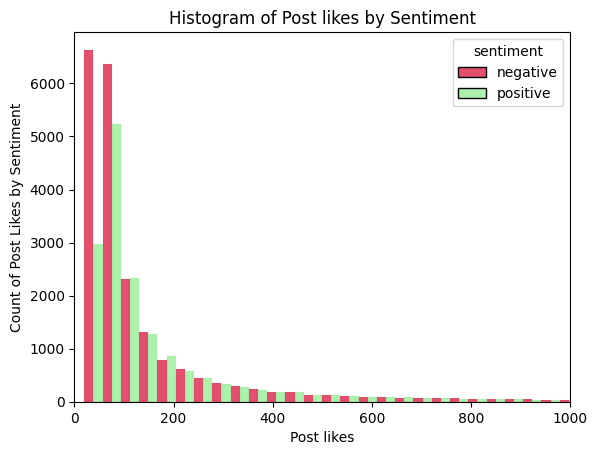

In [ ]:
'''POST LIKES'''

df_post_likes = df_str[df_str['post_likes'] != "?"].copy()
df_post_likes['post_likes'] = pd.to_numeric(df_post_likes['post_likes'], errors='coerce')

plot_histogram_by_sentiment(df=df_post_likes,
                            numeric_column='post_likes',
                            x_label = 'Post Likes',
                            x_lim_ub=1000,
                            bins=800)



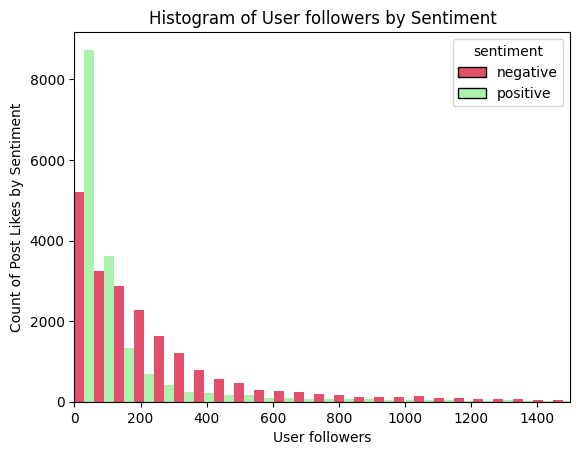

In [ ]:
'''POST FOLLOWERS'''
df_followers = df_str[df_str['post_likes'] != "?"].copy()
df_followers['followers'] = pd.to_numeric(df_followers['followers'], errors='coerce')

plot_histogram_by_sentiment(df=df_followers,
                            numeric_column='followers',
                            x_label = 'User Followers',
                            x_lim_ub=1500,
                            bins=2000)

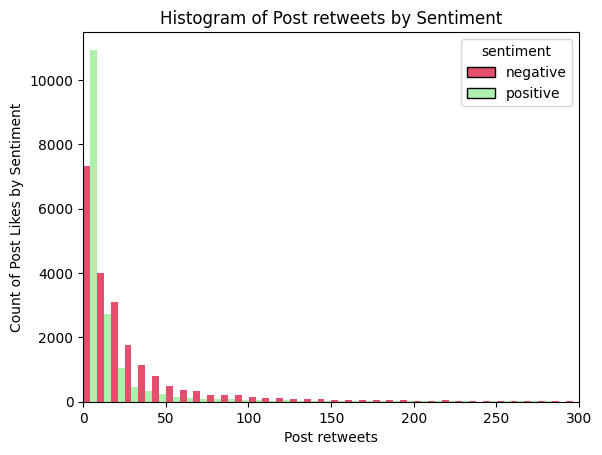

In [ ]:
'''POST RETWEETS'''

df_retweets = df_str[df_str['posts_retweets'] != "?"].copy()
df_retweets['posts_retweets'] = pd.to_numeric(df_retweets['posts_retweets'], errors='coerce')

plot_histogram_by_sentiment(df=df_retweets,
                            numeric_column='posts_retweets',
                            x_label = 'Post Retweets',
                            x_lim_ub=300,
                            bins=2000)

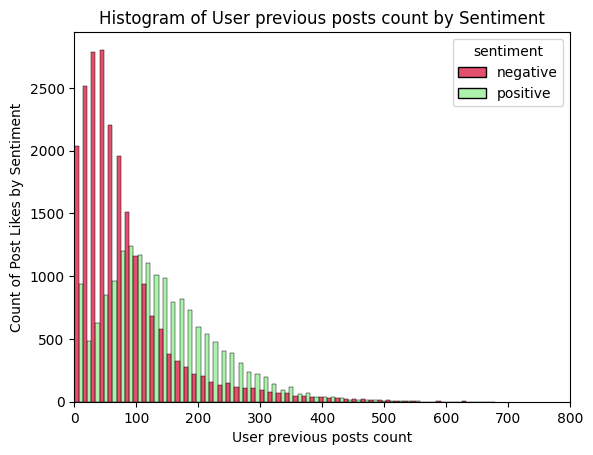

In [ ]:
'''PREVIOUS POSTS COUNT'''
df_previous_posts = df_str[df_str['previous_posts_count'] != "?"].copy()
df_previous_posts['previous_posts_count'] = pd.to_numeric(df_previous_posts['previous_posts_count'], errors='coerce')

plot_histogram_by_sentiment(df=df_previous_posts,
                            numeric_column='previous_posts_count',
                            x_label = 'User Previous Posts Count',
                            x_lim_ub=800,
                            bins=50)

### $\textbf{עיבוד נתונים ויצירת דאטהפריים חדש עם משתנים נוספים}$

In [ ]:
'''PRE-PROCESSING'''

df_analysis = df.copy()

df_analysis = df_analysis.astype('string')


In [ ]:
'''PRE-PROCESSING - CHECKING FOR QUESTION MARKS (MISSING VALUES)'''

rows_with_question_marks = df.apply(lambda row: row.str.contains('\?').any(), axis=1).sum()

print(f"Number of rows with at least one question mark: {rows_with_question_marks}")

df_clean_target = df[df['sentiment'] != "?"]
rows_with_question_marks_excluding_target = df_clean_target.apply(lambda row: row.str.contains('\?').any(), axis=1).sum()
print(f"Number of rows with at least one question mark excluding the missing values in the target variable: {rows_with_question_marks_excluding_target}")



Number of rows with at least one question mark: 2000
Number of rows with at least one question mark excluding the missing values in the target variable: 1473


In [ ]:
'''PRE-PROCESSING - CHECKING FOR DUPLICATES'''
df_analysis.duplicated().sum()     # count duplicates


np.int64(0)

In [ ]:
'''REMOVING OUTLIERS USING THE IQR METHOD'''

def remove_outliers_iqr(df):
    """
    Removes outliers from all numerical columns in the DataFrame using the IQR method.

    Parameters:
        df (pd.DataFrame): The input DataFrame.

    Returns:
        pd.DataFrame: A new DataFrame with outliers removed.
    """
    df_clean = df.copy()
    numeric_cols = df_clean.select_dtypes(include='number').columns

    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df_clean[col] >= Q1 - 1.5 * IQR) & (df_clean[col] <= Q3 + 1.5 * IQR)
        df_clean = df_clean[mask]

    return df_clean


In [ ]:
'''FILTERED DATAFRAME'''

df_analysis = remove_outliers_iqr(df_analysis)



In [ ]:
'''PRE-PROCESSING - CHECKING FOR QUESTION MARKS (MISSING VALUES) AFTER REMOVING OUTLIERS'''

rows_with_question_marks_outliers_removed = df_analysis.apply(lambda row: row.str.contains('\?').any(), axis=1).sum()

print(f"Number of rows with at least one question mark after removing outliers: {rows_with_question_marks_outliers_removed}")


Number of rows with at least one question mark after removing outliers: 2000


In [ ]:
'''PRE-PROCESSING - REMOVING SAMPLES WHERE THERE ARE AT LEAST THAN 8 MISSING VALUES'''

# Count number of '?' per row
missing_counts = (df_analysis == "?").sum(axis=1)

# Keep only rows with fewer than 8 question marks
df_analysis = df_analysis[missing_counts < 8]


In [ ]:
'''PRE-PROCESSING - CHECKING FOR QUESTION MARKS (MISSING VALUES) AFTER REMOVING SAMPLES WITH AT LEAST 8 MISSING VALUES'''

rows_with_question_marks_extreme = df_analysis.apply(lambda row: row.str.contains('\?').any(), axis=1).sum()

print(f"Number of rows with at least one question mark after handling extreme number of missing values: {rows_with_question_marks_extreme}")

Number of rows with at least one question mark after handling extreme number of missing values: 1520


In [ ]:
'''PRE-PROCESSING - HANDLING MISSING VALUES PER COLUMN'''
df_analysis = df_analysis[df_analysis['sentiment'] != "?"]


In [ ]:
def fill_categorical_missing_by_probability_columns(df, columns):
    if isinstance(columns, str):
        columns = [columns]  # if a single column is passed as a string, make it a list

    for column in columns:
        # Replace "?" with np.nan first
        df[column] = df[column].astype(str)
        df[column] = df[column].replace("?", np.nan)

        # Get non-missing values
        non_missing = df[column].dropna()

        if non_missing.empty:
            continue  # skip if no non-missing values to sample from

        # Calculate probabilities for each category
        value_counts = non_missing.value_counts(normalize=True)

        # Find missing indexes (rows) that need to be filled
        missing_idx = df[df[column].isna()].index

        if len(missing_idx) == 0:
            continue  # skip if there are no missing values

        # Randomly sample based on probabilities
        sampled_values = np.random.choice(value_counts.index, size=len(missing_idx), p=value_counts.values)

        # Fill missing
        df.loc[missing_idx, column] = sampled_values

    return df


In [ ]:
def fill_numerical_missing_columns(df, columns):
    if isinstance(columns, str):
        columns = [columns]  # if a single column is passed as a string, make it a list

    for column in columns:
        # Convert column to string to identify '?'
        df[column] = df[column].astype('string')
        df[column] = df[column].replace("?", np.nan)
        non_missing = df[column].dropna()

        non_missing_values = pd.to_numeric(df[column], errors='coerce')  # convert to float
        df[column] = pd.to_numeric(df[column], errors='coerce')  # convert to float

        median_value = non_missing_values.median()

        # Replace '?' with the median value
        df[column] = df[column].fillna(median_value)

        # Convert the column back to numeric after replacing '?' with the median
        df[column] = pd.to_numeric(df[column], errors='coerce')

    return df

In [ ]:
df_analysis = fill_numerical_missing_columns(df_analysis, ['post_likes','posts_retweets','followers','previous_posts_count'])

In [ ]:
df_analysis = fill_categorical_missing_by_probability_columns(df_analysis, ['type', 'checkmark', 'timezone'])

In [ ]:
# converting numerical columns to numeric data type
df_analysis['post_likes'] = pd.to_numeric(df_analysis['post_likes'], errors='coerce')
df_analysis['posts_retweets'] = pd.to_numeric(df_analysis['posts_retweets'], errors='coerce')
df_analysis['followers'] = pd.to_numeric(df_analysis['followers'], errors='coerce')
df_analysis['previous_posts_count'] = pd.to_numeric(df_analysis['previous_posts_count'], errors='coerce')

# setting datetime-type columns
df_analysis['post_datetime'] = pd.to_datetime(df_analysis['post_datetime'], errors='coerce')
df_analysis['account_creation_date'] = pd.to_datetime(df_analysis['account_creation_date'], errors='coerce')
df_analysis['birthday'] = pd.to_datetime(df_analysis['birthday'], errors='coerce')

In [ ]:
'''CHECKING FOR QUESTION MARKS (MISSING VALUES) AFTER FILLING MISSING VALUES'''

rows_with_question_marks_assigned_values = df_analysis.apply(lambda row: row.str.contains('\?').any(), axis=1).sum()

print(f"Number of rows with at least one question mark after assigning values: {rows_with_question_marks_assigned_values}")

Number of rows with at least one question mark after assigning values: 0


In [ ]:
'''PRE-PROCESSING - CONVERTING DATA TYPES AND FORMATTING'''

'''MONTH OF POST'''
df_analysis['month_of_post'] = df_analysis['post_datetime'].dt.month_name() # January, February...

from zoneinfo import ZoneInfo
'''LOCALIZED POST DATETIME'''
df_analysis['localized_post_datetime'] = [
    localize_post_time(post_time, timezone)
    for post_time, timezone in zip(df_analysis['post_datetime'], df_analysis['timezone'])
]



In [ ]:
'''MANIPULATING VARIABLES AFTER PRE-PROCESSING'''
'''ASSUMPTION: ALL OF THE DATA TYPES ARE COORDINATED AND ALIGNED'''

'''REGION'''
df_analysis['region'] = df_analysis['timezone'].map(timezone_to_region)
df_analysis['region'] = df_analysis['region'].astype('string')


'''DAY OF WEEK'''
df_analysis['day_of_week'] = df_analysis['post_datetime'].dt.day_name()
df_analysis['day_of_week'] = df_analysis['day_of_week'].astype('string')


'''AGE'''
# transform birthday to age at post using apply
df_analysis['age'] = df_analysis.apply(lambda row: calculate_age(row['birthday'], row['localized_post_datetime']), axis=1)
df_analysis['age'] = pd.to_numeric(df_analysis['age'])

'''LOCALIZED SLOT OF DAY'''
df_analysis['localized_slot_of_day'] = df_analysis['localized_post_datetime'].apply(get_slot_of_day)
df_analysis['localized_slot_of_day'] = df_analysis['localized_slot_of_day'].astype('string')


'''DAILY POST RETWEET RATE'''
df_analysis['daily_retweet_rate'] = df_analysis['posts_retweets'] / 30
df_analysis['daily_retweet_rate'] = pd.to_numeric(df_analysis['daily_retweet_rate'])



'''ACCOUNT SENIORITY (AGE AT POST) IN WEEKS'''
# calculating account seniority in weeks according to post date
df_analysis['account_seniority_days'] = (df_analysis['post_datetime'] - df_analysis['account_creation_date']).dt.days
df_analysis['account_seniority_days'] = pd.to_numeric(df_analysis['account_seniority_days'])

df_analysis['account_seniority_weeks'] = df_analysis['account_seniority_days'] / 7
# replacing 0 weeks with 1 to avoid division by zero
df_analysis['account_seniority_weeks'] = df_analysis['account_seniority_weeks'].replace(0, 1)
df_analysis['account_seniority_weeks'] = pd.to_numeric(df_analysis['account_seniority_weeks'])


'''POSTS PER WEEK'''
# calculating posts per week
df_analysis['posts_per_week'] = df_analysis['previous_posts_count'] / df_analysis['account_seniority_weeks']
df_analysis['posts_per_week'] = pd.to_numeric(df_analysis['posts_per_week'])



'''FOLLOWERS PER WEEK'''
df_analysis['followers_per_week'] = df_analysis['followers'] / df_analysis['account_seniority_weeks']
df_analysis['followers_per_week'] = pd.to_numeric(df_analysis['followers_per_week'])


'''FOLLOWERS TO PREVIOUS POSTS RATE'''
df_analysis['followers_to_previous_posts'] = df_analysis['followers'] / df_analysis['previous_posts_count']
df_analysis['followers_to_previous_posts'] = pd.to_numeric(df_analysis['followers_to_previous_posts'])


'''LIKES TO RETWEETS RATE'''
df_analysis['likes_to_retweets_rate'] = (df_analysis['post_likes'] / df_analysis['posts_retweets'])
df_analysis['likes_to_retweets_rate'] = pd.to_numeric(df_analysis['likes_to_retweets_rate'])


'''LIKES TO FOLLOWERS RATE'''
df_analysis['likes_to_followers_rate'] = df_analysis['post_likes'] / df_analysis['followers']
df_analysis['likes_to_followers_rate'] = pd.to_numeric(df_analysis['likes_to_followers_rate'])


'''TEXT WORD COUNT'''
df_analysis['text_word_count'] = df_analysis['text'].apply(lambda x: len(x.split()))
df_analysis['text_word_count'] = pd.to_numeric(df_analysis['text_word_count'])


'''TEXT # COUNT'''
df_analysis['hashtag_count'] = df_analysis['text'].apply(lambda x: len([word for word in x.split() if word.startswith('#')]))
df_analysis['hashtag_count'] = pd.to_numeric(df_analysis['hashtag_count'])


'''ATTACHED CONTENT TYPE IN POST'''
df_analysis['attached_content_type'] = df_analysis['embedded_content_url'].apply(classify_and_get_content_type)
df_analysis['attached_content_type'] = df_analysis['attached_content_type'].astype('string')


'''USER HAS PROFILE PICTURE'''
df_analysis['user_has_profile_picture'] = df_analysis['profile_picture'].apply(
    lambda x: 0 if pd.isna(x) or x == "?" else 1
)
df_analysis['user_has_profile_picture'] = pd.to_numeric(df_analysis['user_has_profile_picture'])



'''COMBINED FEATURE FOR ATTACHED CONTENT TYPE AND PICTURE'''
df_analysis['attached_content_and_picture_status'] = df_analysis.apply(
    lambda row: f"{row['attached_content_type']}_with_pic" if row['user_has_profile_picture'] == 1 else f"{row['attached_content_type']}_no_pic",
    axis=1
)
df_analysis['attached_content_and_picture_status'] = df_analysis['attached_content_and_picture_status'].astype('string')


'''COMBINED FEATURE FOR CHECKMARK (TYPE OF ACCOUNT) AND PROFILE PICTURE'''
df_analysis['profile_picture_and_checkmark_status'] = df_analysis.apply(
    lambda row: f"{row['user_has_profile_picture']}_{row['checkmark']}", axis=1)
df_analysis['profile_picture_and_checkmark_status'] = df_analysis['profile_picture_and_checkmark_status'].astype('string')


'''COMBINED FEATURE FOR PROFILE PICTURE AND USERNAME IN EMAIL'''

'''IS USERNAME DOMAIN IN EMAIL?'''
df_analysis['username_in_email_soft'] = df_analysis.apply(
    lambda row: username_in_email_soft(row['username'], row['email']),
    axis=1
)

df_analysis['similar_domain_and_picture'] = df_analysis.apply(
    lambda row: f"{'Yes' if row['user_has_profile_picture'] else 'No'} Picture / " +
                f"{'Yes' if row['username_in_email_soft'] else 'No'} Username in Email",
    axis=1
)




'''LOG SCALED VARIABLES'''
df_analysis['log_scaled_post_likes'] = np.log(df_analysis['post_likes'])

df_analysis['log_scaled_posts_retweets'] = np.log(df_analysis['posts_retweets'])

df_analysis['log_scaled_age'] = np.log(df_analysis['age'])

df_analysis['log_scaled_followers'] = np.log(df_analysis['followers'])

df_analysis['log_scaled_previous_posts_count'] = np.log(df_analysis['previous_posts_count'])

df_analysis['log_scaled_account_seniority_weeks'] = np.log(df_analysis['account_seniority_weeks'])

df_analysis['log_scaled_followers_to_previous_posts'] = np.log(df_analysis['followers'] / df_analysis['previous_posts_count'])

df_analysis['log_scaled_likes_to_retweets'] = np.log(df_analysis['post_likes'] / df_analysis['posts_retweets'])

df_analysis['log_scaled_likes_to_followers'] = np.log(df_analysis['post_likes'] / df_analysis['followers'])

df_analysis['log_scaled_word_count'] = np.log(df_analysis['text_word_count'])

df_analysis['log_scaled_hashtag_count'] = np.log(df_analysis['hashtag_count'])

df_analysis['log_scaled_posts_per_week'] = np.log(df_analysis['posts_per_week'])



/usr/local/lib/python3.11/dist-packages/pandas/core/arrays/masked.py:672: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arrays/masked.py:672: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arrays/masked.py:672: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arrays/masked.py:672: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arrays/masked.py:672: RuntimeWarning: divide by zero encountere

$\textbf{תרשימים לניתוח משתנים מעובדים}$

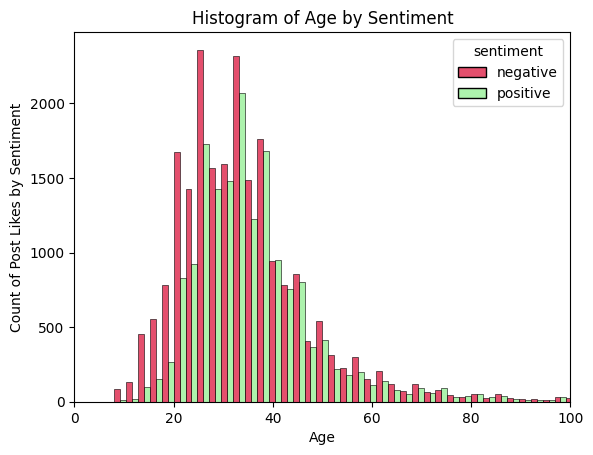

In [ ]:
'''VISUALIZATIONS OF MANIPULATED AND TRANSFORMED DATA'''

'''AGE'''

plot_histogram_by_sentiment(df=df_analysis, numeric_column='age', x_label = 'Age',
                              x_lim_lb=0,x_lim_ub=100,bins=40)

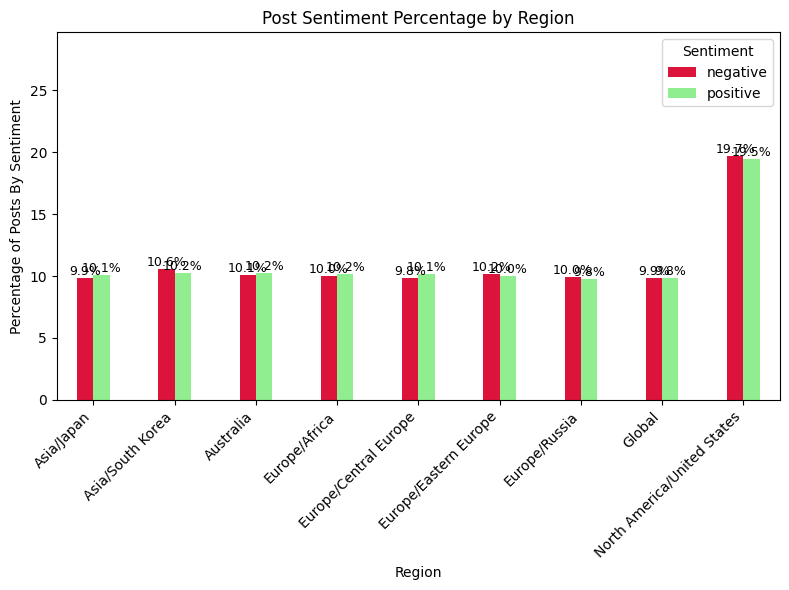

In [ ]:
'''REGION'''
plot_normalized_by_category(df=df_analysis,
                            categorical_column ='region',
                            x_label="Region",
                            figsize=(8,6))

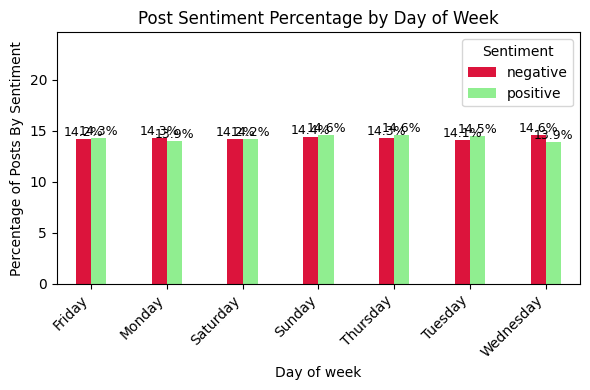

In [ ]:
'''DAY OF WEEK'''
plot_normalized_by_category(df_analysis,
                            categorical_column = 'day_of_week',
                            x_label="Day of Week")

In [ ]:
'''DAILY POST RETWEET RATE'''
plot_histogram_by_sentiment(df=df_analysis,
                            numeric_column='daily_retweet_rate',
                            x_label = 'Daily Retweet Rate',
                            x_lim_ub=80,
                            bins=200)

In [ ]:
'''ACCOUNT SENIORITY (AGE AT POST) IN WEEKS'''
plot_histogram_by_sentiment(df=df_analysis,
                            numeric_column='account_seniority_weeks',
                            x_label = 'Account Seniority (Weeks)')

In [ ]:
'''POSTS PER WEEK'''
plot_histogram_by_sentiment(df=df_analysis,
                            numeric_column='posts_per_week',
                            x_label = 'Posts Per Week')

In [ ]:
'''MONTH OF POST'''
plot_normalized_by_category(df_analysis,
                            categorical_column = 'month_of_post',
                            x_label="Month of Post")

In [ ]:
'''FOLLOWERS GAINED PER WEEK'''
plot_histogram_by_sentiment(df=df_analysis,
                            numeric_column='new_followers_per_week',
                            x_label = 'New Followers Per Week')

In [ ]:
'''FOLLOWERS TO PREVIOUS POSTS RATE'''
plot_histogram_by_sentiment(df=df_analysis,
                            numeric_column='followers_to_previous_posts',
                            x_label = 'Followers to Previous Posts Rate')

In [ ]:
'''LIKES TO RETWEETS RATE'''
plot_histogram_by_sentiment(df=df_analysis,
                            numeric_column='likes_to_retweets_rate',
                            x_label = 'Likes to Retweets Rate')

In [ ]:
'''LIKES TO FOLLOWERS RATE'''
plot_histogram_by_sentiment(df=df_analysis,
                            numeric_column='likes_to_followers_rate',
                            x_label = 'Likes to Followers Rate')

In [ ]:
'''TEXT WORD COUNT'''
plot_histogram_by_sentiment(df=df_analysis,
                            numeric_column='text_word_count',
                            x_label = 'Text Word Count')

In [ ]:
'''HASHTAG COUNT'''
plot_histogram_by_sentiment(df=df_analysis,
                            numeric_column='hashtag_count',
                            x_label = 'Hashtag Count')

In [ ]:
'''USER HAS PROFILE PICTURE'''
plot_normalized_by_category(df_analysis,
                            categorical_column = 'user_has_profile_picture',
                            x_label="User Has Profile Picture")

In [ ]:
'''COMBINED FEATURE FOR ATTACHED CONTENT TYPE AND PICTURE'''
plot_normalized_by_category(df_analysis,
                            categorical_column = 'attached_content_and_picture_status',
                            x_label="Attached Content Type and Picture Status")

In [ ]:
'''COMBINED FEATURE FOR CHECKMARK (TYPE OF ACCOUNT) AND PROFILE PICTURE'''
plot_normalized_by_category(df_analysis,
                            categorical_column = 'profile_picture_and_checkmark_status',
                            x_label="Profile Picture and Checkmark Status")

In [ ]:
'''COMBINED FEATURE FOR USERNAME IN EMAIL'''
plot_normalized_by_category(df_analysis,
                            categorical_column = 'username_in_email_soft',
                            x_label="Username in Email")

In [ ]:
'''COMBINED FEATURE FOR SIMILAR DOMAIN AND PICTURE'''
plot_normalized_by_category(df_analysis,
                            categorical_column = 'similar_domain_and_picture',
                            x_label="Similar Domain and Picture")

In [ ]:
'''SLOT OF DAY'''
time_window_order = ['Morning','Noon', 'Afternoon', 'Evening', 'Night']
plot_normalized_by_category(df_analysis,
                            categorical_column = 'localized_slot_of_day',
                            x_label="Localized Slot of Day",
                            order=time_window_order)


In [ ]:
'''ATTACHED CONTENT TYPE'''
plot_normalized_by_category(df_analysis,
                            categorical_column = 'attached_content_type',
                            x_label="Attached Content Type")

### $\textbf{ניתוח התוכן של הטקסט}$

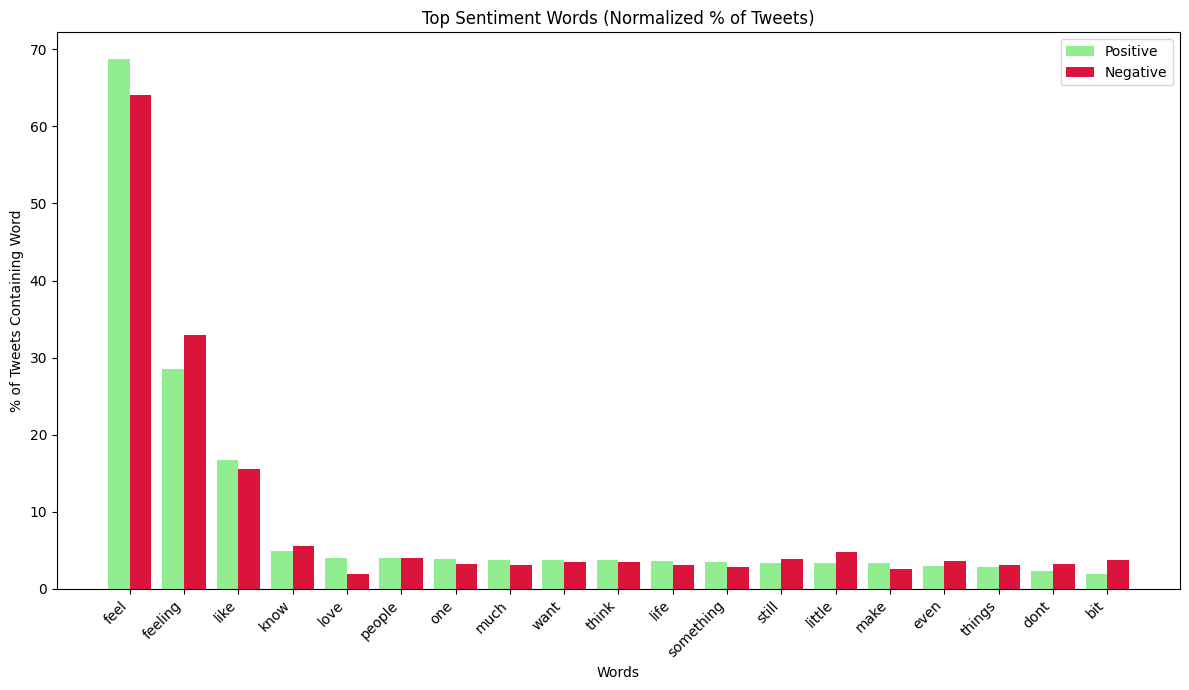

In [ ]:
# SETTINGS
text_col = "text"             # <-- your column with tweet text
sentiment_col = "sentiment"   # <-- your column with sentiment
n_words = 15                  # <-- top N words to compare


# Basic cleaner
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|@\w+|#\w+", "", text)  # remove URLs, mentions, hashtags
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r"\d+", "", text)
    return text

# Custom stopwords (including the ones you've specified)
custom_stopwords = set(stopwords.words("english"))| {"im", "really", "time", "get", "would","ive","nan"}

# Get % of tweets containing each word
def get_word_percentages(df_subset):
    tweet_count = len(df_subset)
    word_counter = Counter()

    for tweet in df_subset[text_col].dropna():
        cleaned = clean_text(tweet)
        words = set(cleaned.split()) - custom_stopwords  # unique words per tweet excluding custom stopwords
        word_counter.update(words)

    # Convert to % of tweets containing each word
    for word in word_counter:
        word_counter[word] = word_counter[word] / tweet_count * 100

    return word_counter

# Get percentages for positive & negative
pos_words = get_word_percentages(df_analysis[df_analysis[sentiment_col] == "positive"])
neg_words = get_word_percentages(df_analysis[df_analysis[sentiment_col] == "negative"])

# Get top N from each
top_pos = [word for word, _ in pos_words.most_common(n_words)]
top_neg = [word for word, _ in neg_words.most_common(n_words)]

# Union of both lists
all_top_words = list(set(top_pos + top_neg))

# Collect into dataframe
data = {
    "word": [],
    "positive %": [],
    "negative %": []
}

for word in all_top_words:
    data["word"].append(word)
    data["positive %"].append(pos_words.get(word, 0))
    data["negative %"].append(neg_words.get(word, 0))

df_freq = pd.DataFrame(data)
df_freq = df_freq.sort_values(by=["positive %", "negative %"], ascending=False)

# Plotting
plt.figure(figsize=(12, 7))
x = range(len(df_freq))
width = 0.4

plt.bar([i - width/2 for i in x], df_freq["positive %"], width=width, label="Positive", color='lightgreen')
plt.bar([i + width/2 for i in x], df_freq["negative %"], width=width, label="Negative", color='crimson')

plt.xticks(x, df_freq["word"], rotation=45, ha='right')
plt.xlabel("Words")
plt.ylabel("% of Tweets Containing Word")
plt.title("Top Sentiment Words (Normalized % of Tweets)")
plt.legend()
plt.tight_layout()


plt.show()

$\textbf{bi-gram (2-gram) analysis}$

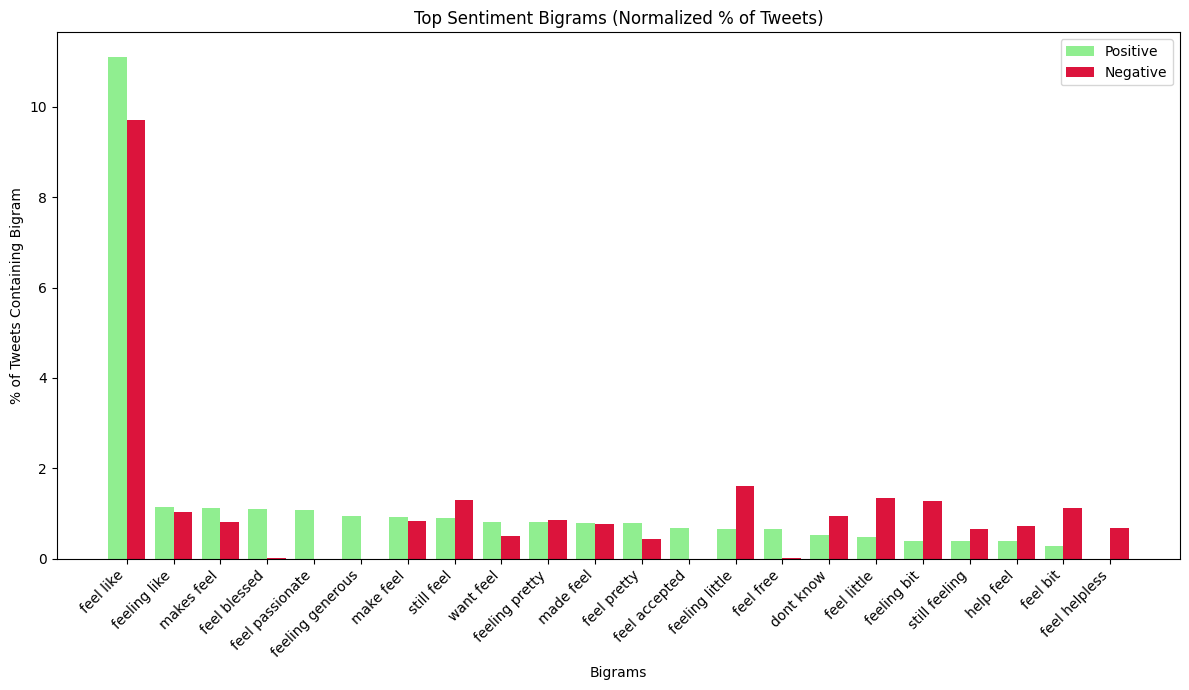

In [ ]:
''' bi-gram (2-gram) analysis '''

text_col = "text"             # column with tweet text
sentiment_col = "sentiment"
n_words = 15                  # top N words to compare


# cleans post text for content analysis
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|@\w+|#\w+", "", text)  # remove URLs, mentions, hashtags
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r"\d+", "", text)
    return text

# custom stopwords that won't be addressed in the content analysis
custom_stopwords = set(stopwords.words("english")) | {"im", "really", "time", "get", "would", "ive","href","http","nan"}

# Get % of tweets containing each bigram
def get_bigram_percentages(df_subset):
    tweet_count = len(df_subset)
    bigram_counter = Counter()

    for tweet in df_subset[text_col].dropna():
        cleaned = clean_text(tweet)
        words = [word for word in cleaned.split() if word not in custom_stopwords]
        bigrams = ngrams(words, 2)  # Generate bigrams
        bigram_counter.update(bigrams)

    # Convert to % of tweets containing each bigram
    for bigram in bigram_counter:
        bigram_counter[bigram] = bigram_counter[bigram] / tweet_count * 100

    return bigram_counter

# Get percentages for positive & negative
pos_bigrams = get_bigram_percentages(df_analysis[df_analysis[sentiment_col] == "positive"])
neg_bigrams = get_bigram_percentages(df_analysis[df_analysis[sentiment_col] == "negative"])

# Get top N from each
top_pos_bigrams = [bigram for bigram, _ in pos_bigrams.most_common(n_words)]
top_neg_bigrams = [bigram for bigram, _ in neg_bigrams.most_common(n_words)]

# Union of both lists
all_top_bigrams = list(set(top_pos_bigrams + top_neg_bigrams))

# Collect into dataframe
data = {
    "bigram": [],
    "positive %": [],
    "negative %": []
}

for bigram in all_top_bigrams:
    data["bigram"].append(' '.join(bigram))  # Join the bigram tuple into a string
    data["positive %"].append(pos_bigrams.get(bigram, 0))
    data["negative %"].append(neg_bigrams.get(bigram, 0))

df_freq_bigrams = pd.DataFrame(data)
df_freq_bigrams = df_freq_bigrams.sort_values(by=["positive %", "negative %"], ascending=False)

# Plotting
plt.figure(figsize=(12, 7))
x = range(len(df_freq_bigrams))
width = 0.4

positive_bars = plt.bar([i - width/2 for i in x], df_freq_bigrams["positive %"], width=width, label="Positive", color='lightgreen')
negative_bars = plt.bar([i + width/2 for i in x], df_freq_bigrams["negative %"], width=width, label="Negative", color='crimson')

# Add labels and title
plt.xticks(x, df_freq_bigrams["bigram"], rotation=45, ha='right')
plt.xlabel("Bigrams")
plt.ylabel("% of Tweets Containing Bigram")
plt.title("Top Sentiment Bigrams (Normalized % of Tweets)")
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
top_words = ['feel','feeling','like','know','love','people','one',
             'much','want','think','life','something','still',
             'little','make','even','things','dont','bit']

top_bigrams = ['feel like','feeling like','makes feel','feel blessed','feel passionate','feeling generous','make feel',
               'still feel','want feel','feeling pretty','made feel','feel pretty','feel accepted','feeling little',
               'feel free', 'dont know','feel little','feeling bit','still feeling','help feel','feel bit','feel helpless']

for word in top_words:
    df_analysis[f'has_{word}'] = df['text'].apply(lambda x: int(word in x))

for bigram in top_bigrams:
    df_analysis[f'has_{bigram}'] = df['text'].apply(lambda x: int(bigram in x))



In [ ]:
'''FEATURE REPRESENTATION'''

from sklearn.preprocessing import MinMaxScaler

df_features = df_analysis.copy()
df_features = df_features.drop(columns=['text', 'id','username','email', 'post_datetime', 'timezone', 'embedded_content_url', 'profile_picture', 'account_creation_date', 'birthday','localized_post_datetime'])

df_features = df_features.loc[df_features['day_of_week'].notna()]


categorical_columns = df_features.select_dtypes(exclude=['number']).columns
numerical_columns = df_features.select_dtypes(exclude=['object', 'string', 'bool']).columns



In [ ]:
# for Categorical Columns (One-Hot Encoding)
df_features = pd.get_dummies(df_features, columns=categorical_columns)


In [ ]:
# for Numerical Columns (Min-Max Scaling)
scaler = MinMaxScaler()

df_features['followers_to_previous_posts'] = df_features['followers_to_previous_posts'].dropna()
df_features[numerical_columns] = df_features[numerical_columns].replace([np.inf, -np.inf], np.nan)

# Iterate over each numerical column
for col in numerical_columns:
    max_value = df_features[col].max()  # Get the maximum value for the column
    df_features[col] = df_features[col].fillna(max_value)  # Fill missing values with the max value


df_features[numerical_columns] = scaler.fit_transform(df_features[numerical_columns])

In [ ]:
'''FEATURE SELECTION'''

features = df_features.copy()
# Create a new column: 1 if sentiment_positive is 1, 0 if sentiment_negative is 1
features['sentiment_bool'] = features.apply(
    lambda row: 1 if row['sentiment_positive'] == 1 else 0,
    axis=1
)

target = features['sentiment_bool']
features = features.drop(columns=['sentiment_positive', 'sentiment_negative','sentiment_bool'])


scores = []
for feature in features.columns:
    pos_values = features[feature][target == 1]
    neg_values = features[feature][target == 0]

    mu_pos = pos_values.mean()
    mu_neg = neg_values.mean()
    std_pos = pos_values.std()
    std_neg = neg_values.std()

    denominator = std_pos + std_neg

    if denominator == 0:
        R = np.nan
    else:
        R = abs(mu_pos - mu_neg) / denominator

    scores.append((feature, R))

fischer_score_manual = pd.DataFrame(scores, columns=['Feature', 'R_score'])
fischer_score_manual_sorted = fischer_score_manual.sort_values(by='R_score', ascending=False)
print(fischer_score_manual_sorted.head(50))


                                               Feature   R_score
129                       username_in_email_soft_False  0.892300
130                        username_in_email_soft_True  0.892300
134  similar_domain_and_picture_Yes Picture / Yes U...  0.659144
27                           log_scaled_posts_per_week  0.592730
14                                       hashtag_count  0.552672
24                       log_scaled_likes_to_followers  0.536386
133  similar_domain_and_picture_Yes Picture / No Us...  0.532550
8                                       posts_per_week  0.471091
22              log_scaled_followers_to_previous_posts  0.445973
131  similar_domain_and_picture_No Picture / No Use...  0.421407
26                            log_scaled_hashtag_count  0.404517
23                        log_scaled_likes_to_retweets  0.357689
20                     log_scaled_previous_posts_count  0.333145
3                                 previous_posts_count  0.325138
19                       

In [ ]:
df_highest_fischer_features = features[['username_in_email_soft_True',
                                         'similar_domain_and_picture_Yes Picture / Yes Username in Email',
                                         'log_scaled_posts_per_week', 'hashtag_count',
                                         'log_scaled_likes_to_followers',
                                         'similar_domain_and_picture_Yes Picture / No Username in Email',
                                         'log_scaled_followers_to_previous_posts',
                                         'log_scaled_likes_to_retweets', 'log_scaled_previous_posts_count',
                                         'log_scaled_followers', 'month_of_post_December',
                                         'month_of_post_November', 'month_of_post_January',
                                         'month_of_post_February', 'checkmark_grey', 'checkmark_gold',
                                         'profile_picture_and_checkmark_status_1_gold',
                                         'profile_picture_and_checkmark_status_1_grey', 'checkmark_none',
                                         'profile_picture_and_checkmark_status_0_none', 'month_of_post_June',
                                         'localized_slot_of_day_Morning']]

